In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

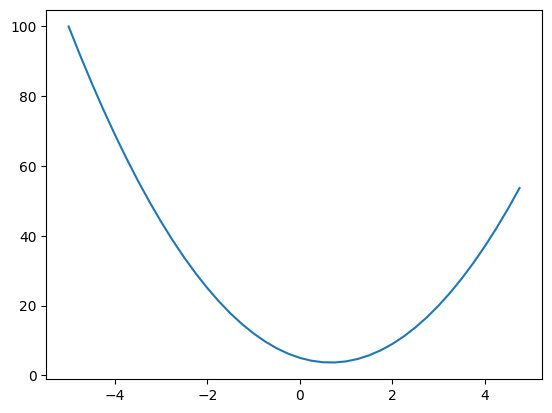

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5     # a parabolic function

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [4]:
def slopeOfTangent(x):
    # Derivative - sensitivity to change of function's output with respect to its input
    # l = (f(x+h) - f(x)) / h   =>  The very definition of derivative
    # h - close to 0
    h = 0.00000001
    y = f(x)
    yh = f(x + h)
    l = (yh - y) / h     # slope
    return l

print(slopeOfTangent(3.0))
    
# '''
# f(x) = 3*x**2 - 4*x + 5
# f'(x) = 6x - 4
# f'(3) = 18 - 4 = 14
# '''

14.00000009255109


In [5]:
x = -3.0
print(f(x))
print(slopeOfTangent(x))

# at -3, the graph goes down if x increases slightly, the slope would be negative

44.0
-22.00000039920269


In [6]:
print(slopeOfTangent(2/3))

0.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10

def d(a, b, c):
    return a*b + c

d1 = d(a, b, c)
d2 = d(a+h, b, c)
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

# '''
# Derivative with respect to a
# Increase to a -> d goes down since b is negative -> so slope is negative
# d = a*b + c
# d' = b = -3.0
# '''

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [8]:
d2 = d(a, b+h, c)
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

# '''
# Derivative with respect to b
# Increase to b -> d goes up since a is positive -> slope is positive
# d = a*b + c
# d' = a = 2
# '''

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [9]:
d2 = d(a, b, c+h)
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)
# '''
# Derivative with respect to c
# Increase to c -> directly proportional to increase in d
# d = a*b + c
# d' = 1
# '''

d1 4.0
d2 4.0001
slope 0.9999999999976694


### micrograd implementation

In [10]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0    # derivative of the loss function L with respect to this value
        self._backward = lambda: None    # Make it none for leaf nodes.
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):  # self + other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # chain rule in addition, refer manual gradient settings done below
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):  # self * other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # chain rule in multiplication, refer manual gradient settings done below
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):  # other * self
        # above mul takes care of a * 2, but 2 * a will throw error
        # since 2.__mul__(a) is not known by python
        # so rmul is kind of a fall back for python, if it can't do 2 * a,
        # python will check if it can do a * 2 which is the responsiblity of rmul here
        return self * other  # self here is Value and other is primitive

    def __pow__(self, other):  # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    '''
    division can be a special case
    a/b can be written as
    a/b = a * (1/b)
    => 1/b = b**(-1)
    => a/b = a * b**(-1)
    and we can x**k is someting we can differntiate
    '''

    def __truediv__(self, other):  # self / other
        return self * other**-1

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __radd__(self, other):  # other + self
        return self + other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)  # tanh
        out = Value(t, (self, ), 'tanh')
        def _backward():
            # chain rule in tanh, refer manual gradient settings done below
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad  # derivative of e**x is e**x
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'

'''
dL/dL = 1
'''
L.grad = 1.0

'''
L = d * f
dL/dd = f
=> (f(x+h) - f(x)) / h
= (((d+h)*f) - (d*h))/h
= (d*f + h*f - d*f) / h
= h*f / h = f
'''
d.grad = -2.0
f.grad = 4.0

'''
Finding dL/dc and dL/de is where real back propagation happens
We have:
dL/dd = -2.0

Now d depends on c and e, so
d = e + c
dd/de = 1.0
dd/dc = 1.0

We need to find:
dL/de and dL/dc

Chain rule of differentiation says:
If z depends on y and y depends on x like
x -> y -> z
dz/dx = (dz/dy) * (dy/dx)
For practical explanation, look under "Intuitive Explanation" in https://en.wikipedia.org/wiki/Chain_rule

=> dL/de = (dL/dd) * (dd/de)
         = -2.0 * 1.0
         = -2.0
=> dL/dc = -2.0
'''
c.grad = -2.0
e.grad = -2.0

'''
Similarly for dL/da and dL/db, we apply chain rule.
a and b produces e
So lets find the local gradients de/da and de/db
e = a * b
de/da = b = -3.0
de/db = a = 2.0

=> dL/da = (dL/de) * (de/da)
         = -2.0 * -3.0
         = 6.0
=> dL/db = (dL/de) * (de/db)
         = -2.0 * 2.0
         = -4.0
'''
a.grad = 6.0
b.grad = -4.0

# '''
# We started from output L, found its derivatives with respect to its local children variables
# and we recursively multiplied their derivatives with their children variables to find L's derivatives
# This is back propagation
# '''

In [11]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

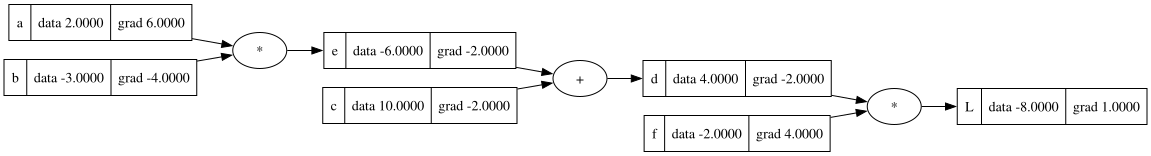

In [12]:
draw_dot(L)

In [13]:
def verify():
    h = 0.0001
    
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    b.data += h
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
verify()

-4.000000000008441


In [14]:
# Let's do a single small optimisation, which is to influence the final output by tweeking the inputs which are leaf nodes in our case
# Leaf nodes - a, b, c, f
# Lets nudge them slightly in the direction of their gradients by multiplying their gradients with a smaller value
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)  # -8 -> -7.2

-7.286496


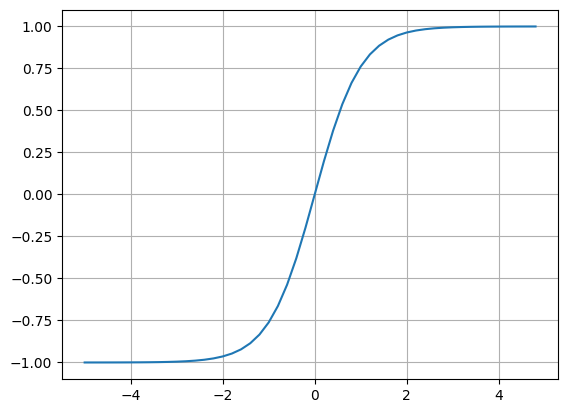

In [15]:
# tanh function
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [16]:
# A single neuron
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# b = Value(8.0, label='b')
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# tanh is our activation function
o = n.tanh(); o.label = 'o'

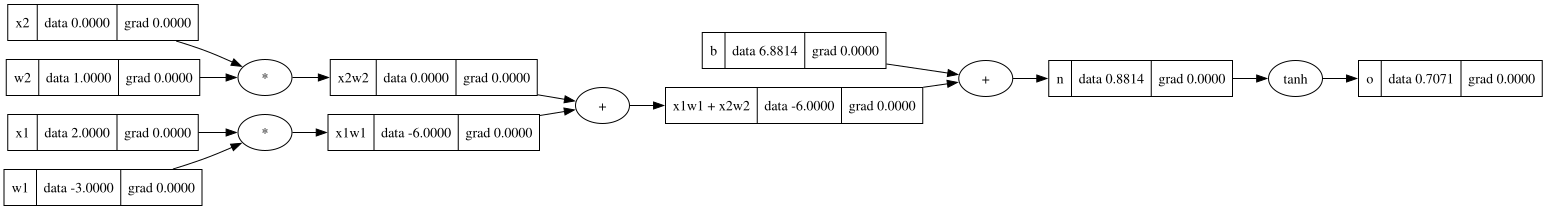

In [17]:
draw_dot(o)

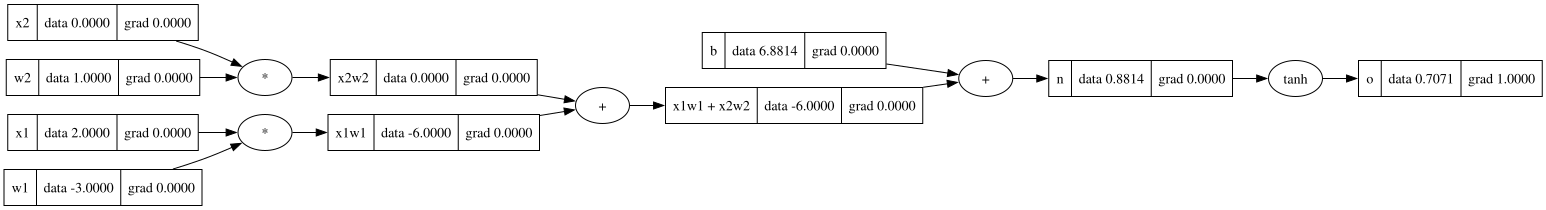

In [18]:
o.grad = 1.0
draw_dot(o)

In [19]:
'''
o = tanh(n)
do/dn = 1 - tanh(n)**2
      = 1 - o**2
'''
1 - o.data**2

0.4999999999999999

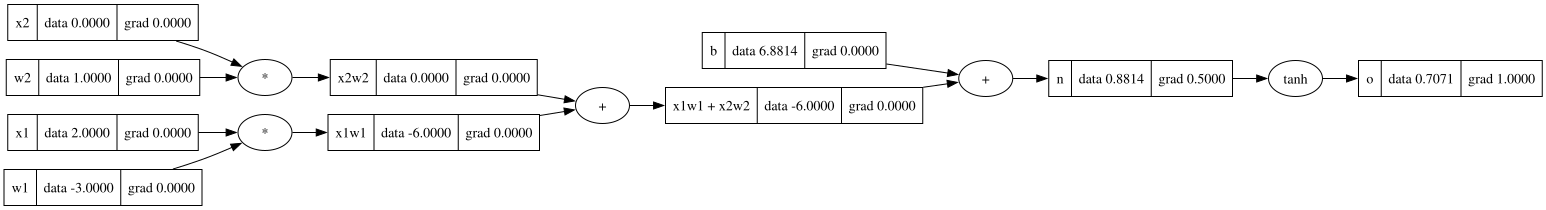

In [20]:
n.grad = 0.5
draw_dot(o)

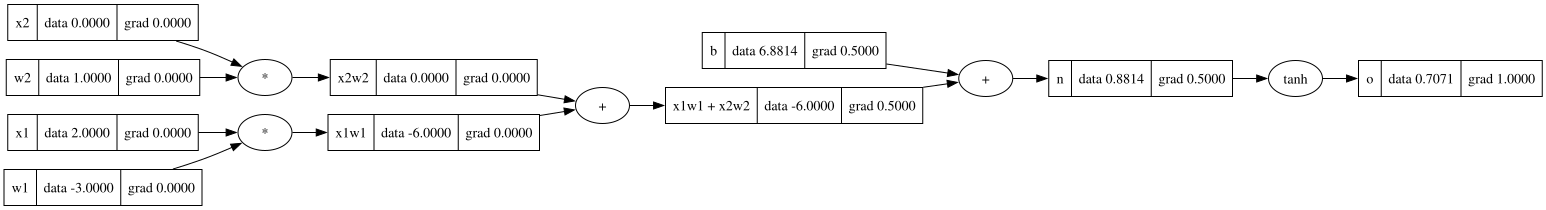

In [21]:
'''
n = x1w1x2w2 + b
Frow last example, '+' is just a derivative distributor backwards
do/db = 1 * 0.5 = 0.5
Same goes to x1w1x2w2
'''
x1w1x2w2.grad = 0.5
b.grad = 0.5
draw_dot(o)

In [22]:
'''
Similarly for x2w2 and x1w1
'''
x1w1.grad = 0.5
x2w2.grad = 0.5

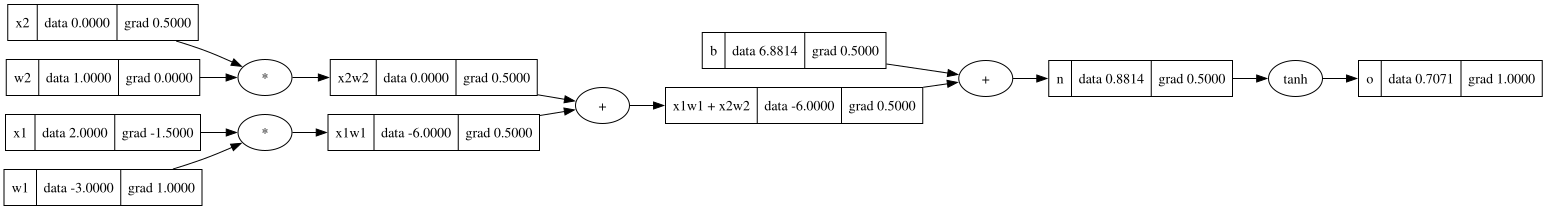

In [23]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

'''
A observation:
w2's gradient becomes 0. 
This means w2 has no effect on changing the output o if increased or decreased.
Mathematically speaking, since w2 is multipled by x2 which is 0, w2 has no weight here in the neuron.
'''

draw_dot(o)

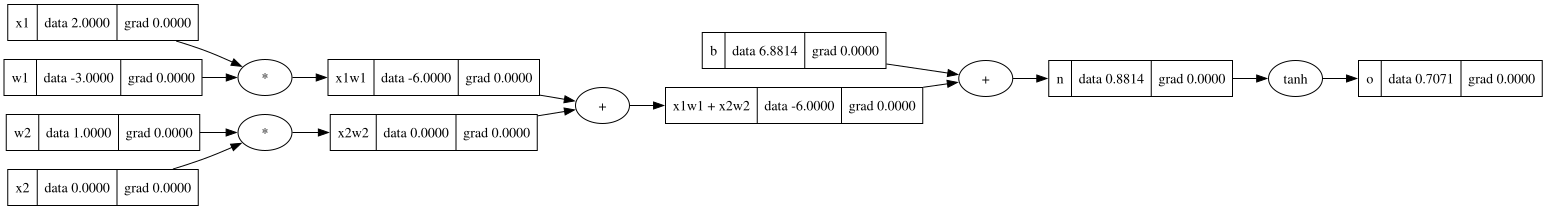

In [24]:
# A single neuron
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# b = Value(8.0, label='b')
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# tanh is our activation function
o = n.tanh(); o.label = 'o'
draw_dot(o)

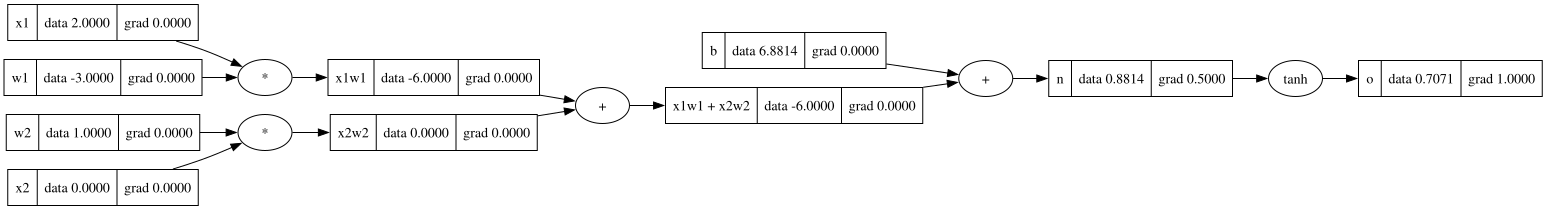

In [25]:
o.grad = 1.0
o._backward()
# now n's grad should be set
draw_dot(o)

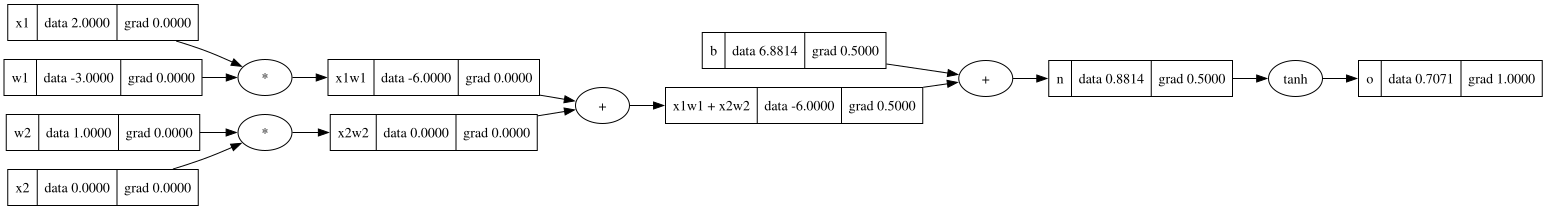

In [26]:
n._backward()
# b and x1w1x2w2 grad will be set
draw_dot(o)

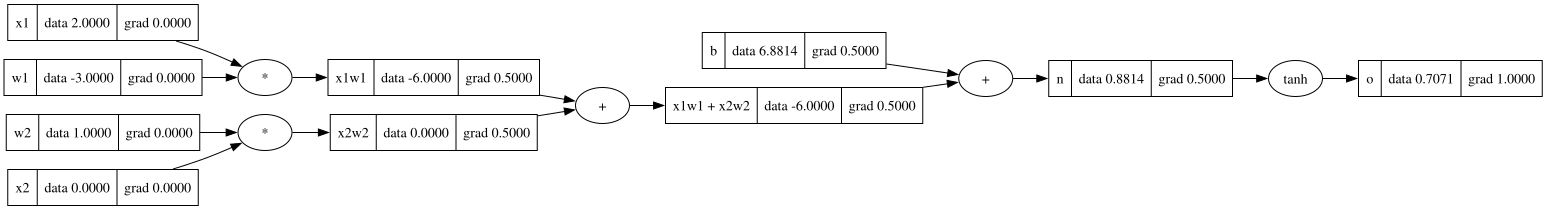

In [27]:
b._backward()    # since b is a leaf node and have no one to back propogate the gradient, it does nothing, just has lambda: None as _backward
x1w1x2w2._backward()
draw_dot(o)

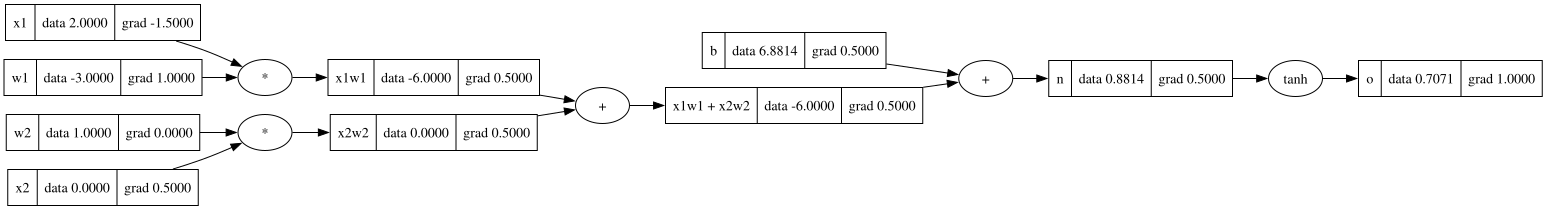

In [28]:
x1w1._backward()
x2w2._backward()
draw_dot(o)

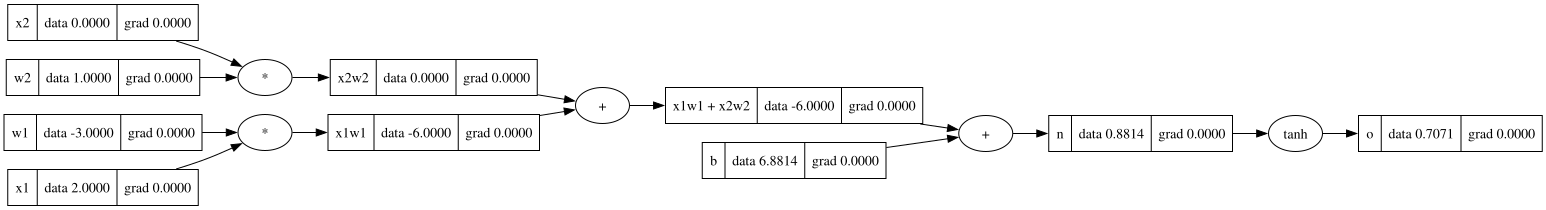

In [29]:
# A single neuron
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# b = Value(8.0, label='b')
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# tanh is our activation function
o = n.tanh(); o.label = 'o'
draw_dot(o)

In [30]:
o.grad = 1.0

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)  # only add to order once all its children are processed

build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

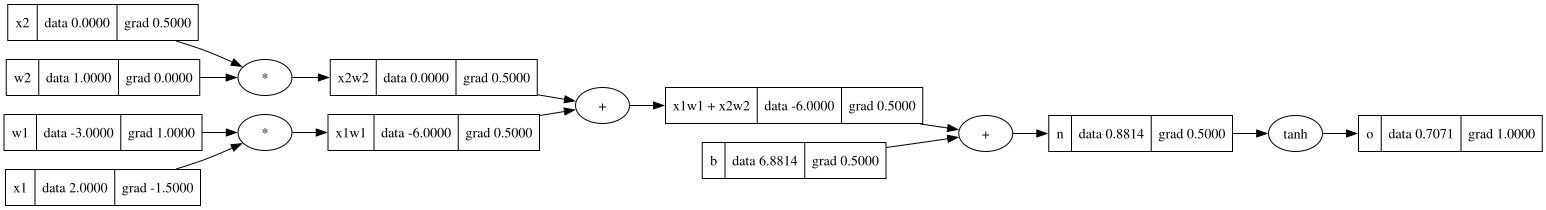

In [31]:
for node in reversed(topo):
    node._backward()

draw_dot(o)

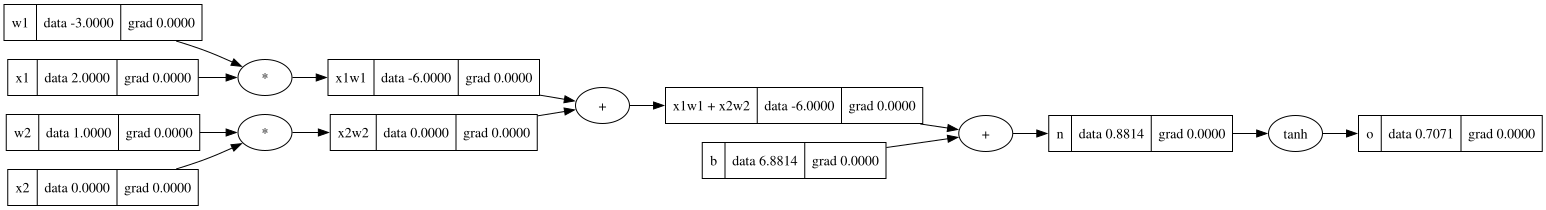

In [32]:
# A single neuron
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# b = Value(8.0, label='b')
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# tanh is our activation function
o = n.tanh(); o.label = 'o'
draw_dot(o)

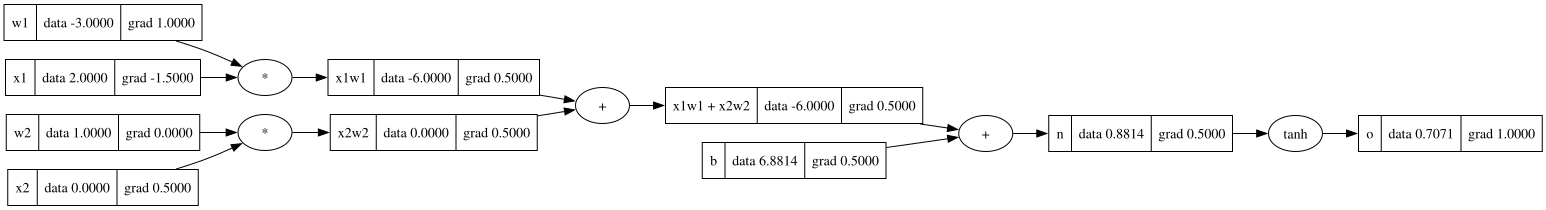

In [33]:
o.backward()
draw_dot(o)
# Now this is back propogation for one neuron

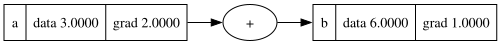

In [34]:
'''
There is a bug in this implementation.
Let's take this example
b = a + a
now, db/da should be 2
But in out implementation, we would get 1
'''
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

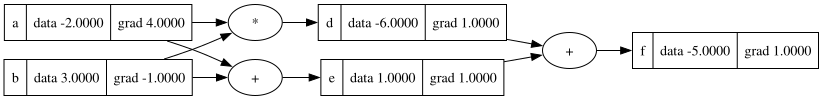

In [35]:
'''
Let's take another example
'''
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d + e; f.label = 'f'
f.backward()
draw_dot(f)

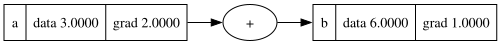

In [36]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

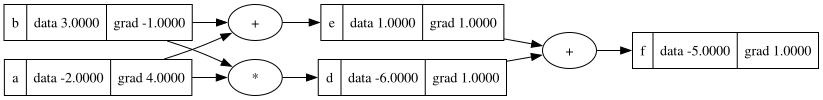

In [37]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d + e; f.label = 'f'
f.backward()
draw_dot(f)

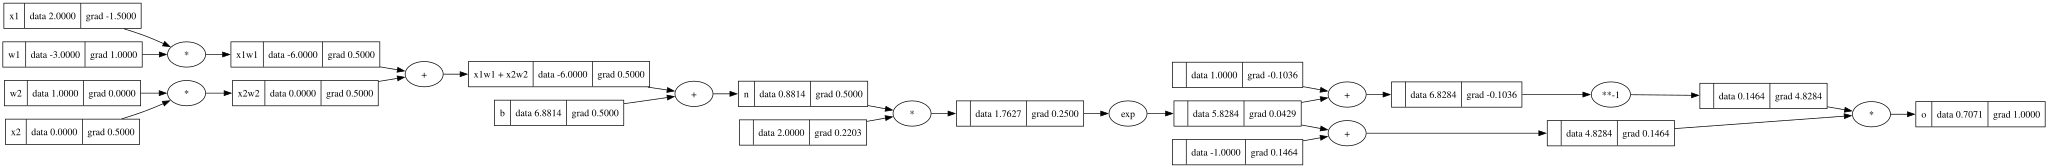

In [38]:
# A single neuron
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
# b = Value(8.0, label='b')
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# tanh is our activation function
# ---
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---
o.label = 'o'
o.backward()
draw_dot(o)

In [39]:
'''
Let's do the same in PyTorch
Our micrograd is built of scalar values, like
x1 = 2.0
x2 = 0.0
In pytorch, a tensor, which is our Value equivalent, is capable of multi dimensions like
x1 = [[1, 2, 3],
      [4, 5, 6]]
'''
import torch

a = torch.Tensor([2.0])
print(a)
print(a.shape)
print(a.dtype)
a = a.double()
print(a.dtype)  # python's default precision is double (float64) when we declared x1 = 0.2 in our micrograd. So explicitly calling double() here
b = torch.Tensor([[1, 2, 3], [4, 5, 6]])
print(b.shape)
print(b.dtype)
print(b)

tensor([2.])
torch.Size([1])
torch.float32
torch.float64
torch.Size([2, 3])
torch.float32
tensor([[1., 2., 3.],
        [4., 5., 6.]])


In [40]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True    # By default gradient is disbaled in pytorch
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w1.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print('x2', x2.grad.item())
print('w2', w1.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 1.0000002567688737
x1 -1.5000003851533106
w1 1.0000002567688737


In [41]:
class Neuron:
    def __init__(self, nin): # nin - no. of inputs
        self.w = [Value(random.uniform(-1, 1), label='w') for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')

    def __call__(self, x):
        # w * x + b
        '''
        x is the inputs arrays
        x = [2.0, 1.0]
        n = Neuron(2)
        n(x) -> calls this method
        '''
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout): # nout - no. of neurons
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:
    def __init__(self, nin, nouts): # nouts - a list, no. of neurons in each layer
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

# x = [2.0, 1.0]
# # n = Neuron(2)
# # n(x)
# l = Layer(2, 3)
# l(x)

In [147]:
'''
Lets build a MLP now with
inputs - 3
hidden1 layer - 4
hidden2 layer - 4
output - 1
'''
x = [2.0, 3.0, -1.0] # 3 inputs
m = MLP(3, [4, 4, 1])
out = m(x)
out

Value(data=-0.9530024977469055)

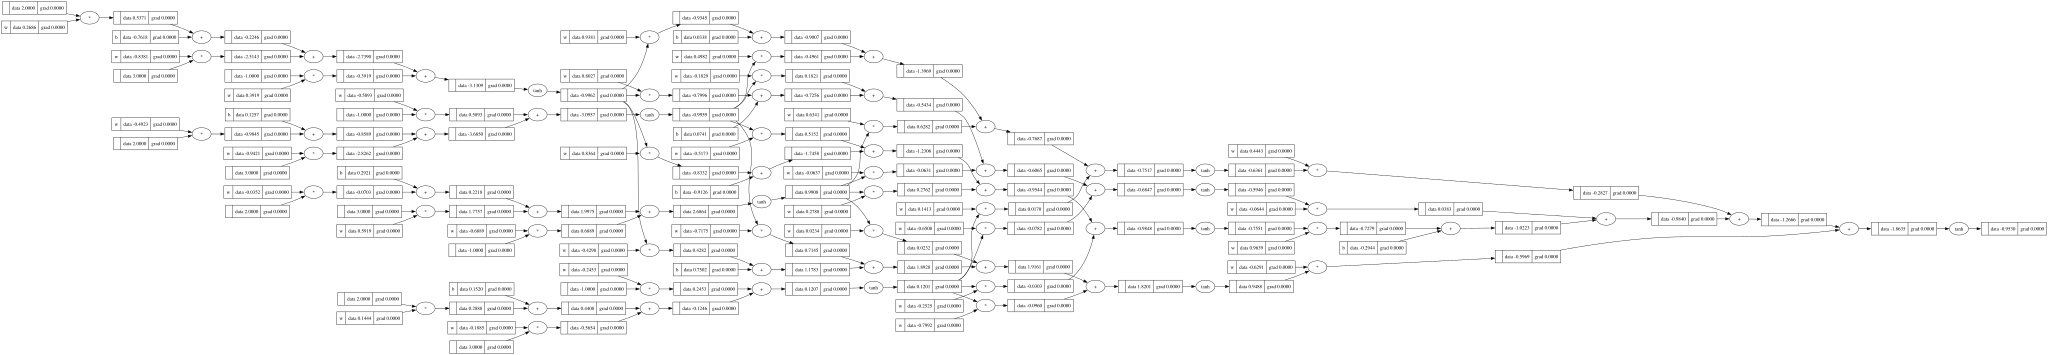

In [148]:
draw_dot(out)

In [149]:
'''
Lets work with this example where we have multiple inputs and have respective desired outputs
'''
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired outputs, one for each set of inputs
ypred = [m(x) for x in xs]
ypred

[Value(data=-0.9530024977469055),
 Value(data=-0.6187188722870633),
 Value(data=-0.9614922093308998),
 Value(data=-0.9488926921774739)]

In [150]:
'''
In respective with ys
ypred1 should go up
ypred2 should go down
ypred3 should go down
ypred4 should go up

This is loss. Loss function is something made out of this, which we try to make smaller so that we can get closer to ys.
We are going to use Squared error function
'''
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.7592596301206775)

In [151]:
loss.backward()

In [153]:
m.layers[0].neurons[0].w[0].grad    # this weight's gradient tells us that this weight has positive influence on our loss value (directly proportional)

0.6824038132878774

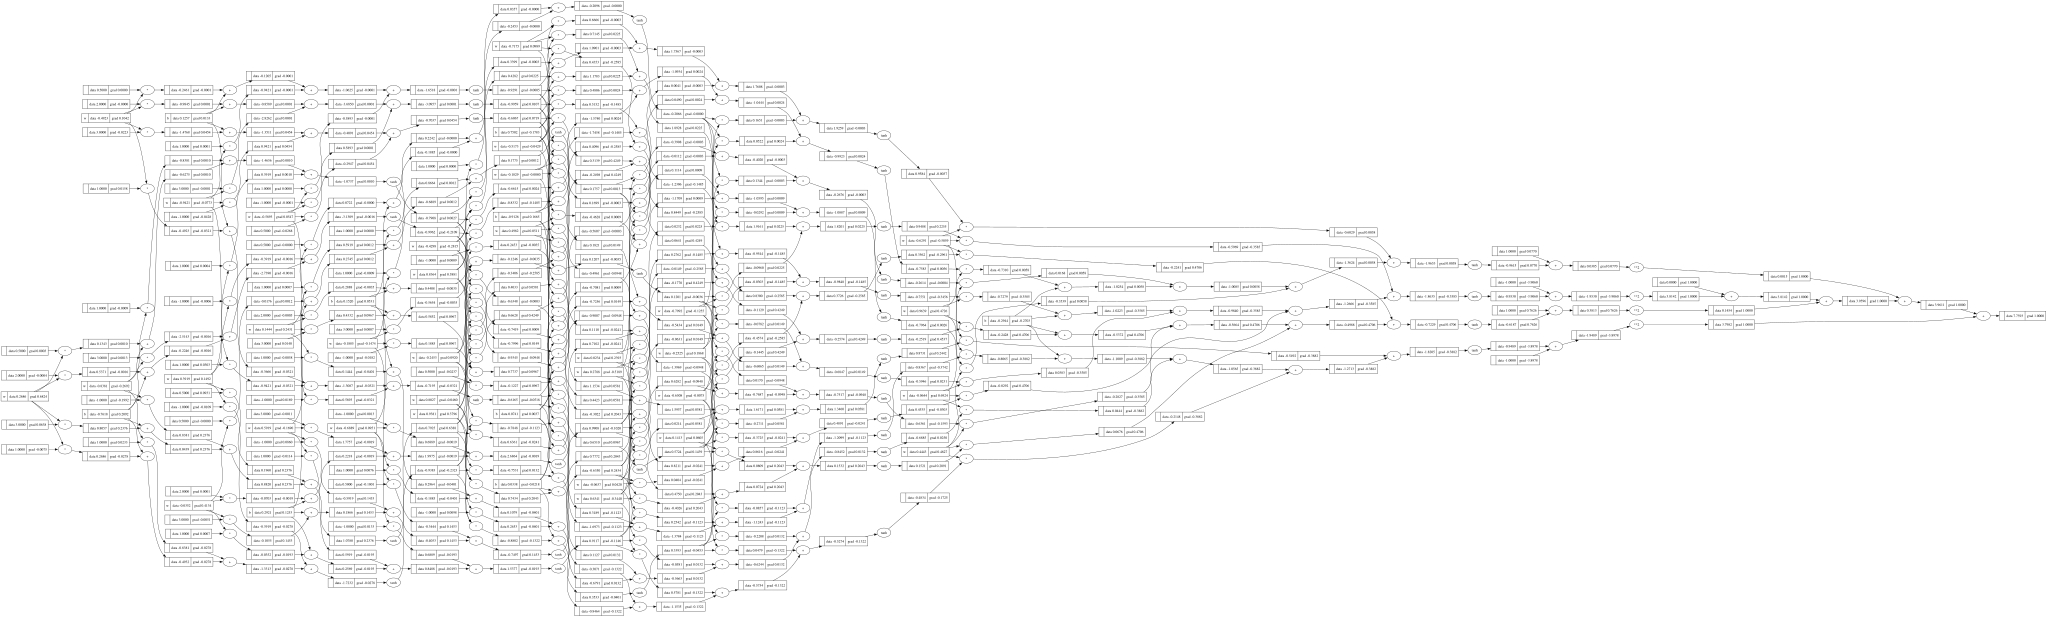

In [154]:
draw_dot(loss)

In [158]:
m.layers[0].neurons[0].w[0].data

0.2685686414461874

In [164]:
print(f"Total parameters: {len(m.parameters())}")

Total parameters: 41


In [165]:
'''
Now let's do gradient descent optimization
If we nudge a little in the direction of the gradient of each parameter, i.e. increase its data by adding to it a tiny multiplier of it grad,
our loss function will grow.
But our target is to reduce the loss function. so we do it in the opposite direction, i.e, decreasing
'''
for p in m.parameters():
    p.data += -0.01 * p.grad   # 0.01 is out small step value multiplier, '-' is decreasing it

In [167]:
m.layers[0].neurons[0].w[0].data  # the data is decreased because it have positive influence on our loss, since it's grad is positive

0.2617446033133086

In [170]:
'''
Now, we do our predictions again and calculate new loss, which we call a forward pass
'''
ypred = [m(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss  # older loss is Value(data=7.7592596301206775) from above which is now lesser

Value(data=7.726227676049854)

In [171]:
# Now backward pass
loss.backward()

In [172]:
# Let's do it again
for p in m.parameters():
    p.data += -0.01 * p.grad

In [173]:
ypred = [m(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.662738357500337)

In [351]:
loss.backward()

In [352]:
# Let's do with a bigger learning rate 0.1
# After tuning learning rate with increasing, decreasing, negating and non-negating multiple times
for p in m.parameters():
    p.data += -0.0001 * p.grad
ypred = [m(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.00010880126603399682)

In [353]:
# Our y pred should be getting closer to desired outputs if we keep doing it.
# Tune learning rate accordingly. Too big, we go way off and end up increasing our loss
ypred

[Value(data=0.999999737773196),
 Value(data=-0.9895695194268459),
 Value(data=-0.9999203701684856),
 Value(data=0.9999997388069115)]

In [354]:
# These are our trained parameters
m.parameters()

[Value(data=1.1435393047413254),
 Value(data=-1.1281175024550496),
 Value(data=1.158945427595067),
 Value(data=-0.002343193813353812),
 Value(data=-0.25450424550664524),
 Value(data=-0.02191120369384827),
 Value(data=-1.4558868820677708),
 Value(data=0.5274611486101272),
 Value(data=-0.9254804513486108),
 Value(data=1.4477216063296319),
 Value(data=-1.3411450672499132),
 Value(data=0.17454249298699034),
 Value(data=-1.1056276541928998),
 Value(data=2.059586661339647),
 Value(data=-2.5726834943268364),
 Value(data=-0.2936246509958369),
 Value(data=-3.2543369701237093),
 Value(data=-2.5339301288092453),
 Value(data=4.398160484194277),
 Value(data=-0.02778228872300438),
 Value(data=1.2760284951200145),
 Value(data=1.1823878165368829),
 Value(data=-0.7693537367455391),
 Value(data=-4.443783443548563),
 Value(data=-2.743734952231348),
 Value(data=0.9529569935199333),
 Value(data=-1.9434306257987146),
 Value(data=-1.2850501005026542),
 Value(data=3.0096802506203435),
 Value(data=0.3778266580

In [359]:
m = MLP(3, [4, 4, 1])

In [360]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired outputs, one for each set of inputs

In [367]:
'''
There is a bug in the above approach that we missed, but we fixed here.
The bug is, we forgot to reset the parameters' grads before a backward pass.
So the grad got accumulated for every pass.
The reason that it worked is because the our data is simple and got converged faster because of it.
'''

for k in range(20):
    # forward pass
    ypred = [m(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward
    for p in m.parameters():
        p.grad = 0.0  # resetting grads
    loss.backward()

    # update
    for p in m.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.010732381113728956
1 0.010583225600172585
2 0.010438026280106405
3 0.010296630136617555
4 0.010158891873830926
5 0.01002467343889785
6 0.009893843578907708
7 0.009766277429792102
8 0.009641856134566707
9 0.009520466488506168
10 0.009402000609067299
11 0.00928635562857738
12 0.009173433407881794
13 0.009063140269308417
14 0.008955386747449431
15 0.008850087356394056
16 0.0087471603721628
17 0.00864652762920131
18 0.00854811432988854
19 0.008451848866101511


In [368]:
ypred

[Value(data=0.9586029393843082),
 Value(data=-0.9464489297190127),
 Value(data=-0.9609712279879972),
 Value(data=0.9515523987644577)]